In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models

np.random.seed(42)
tf.random.set_seed(42)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

base_path = "/content/drive/MyDrive/ML_MED/Prac1/"

train_df = pd.read_csv(base_path + "mitbih_train.csv", header=None)
test_df  = pd.read_csv(base_path + "mitbih_test.csv", header=None)

X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values.astype(int)

X_test  = test_df.iloc[:, :-1].values
y_test  = test_df.iloc[:, -1].values.astype(int)

X_train.shape, y_train.shape, X_test.shape, y_test.shape


((87554, 187), (87554,), (21892, 187), (21892,))

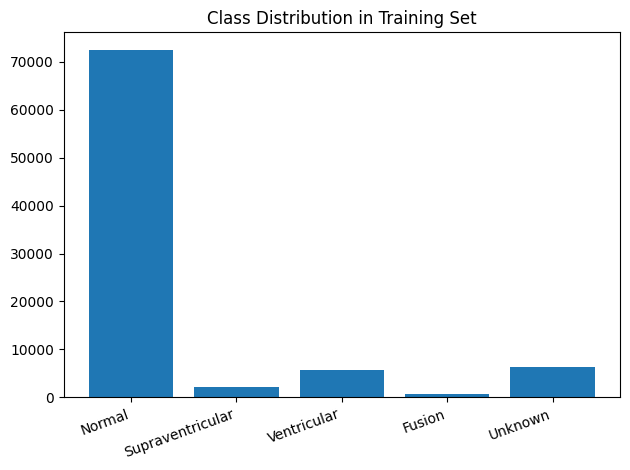

,count
0,72471
1,2223
2,5788
3,641
4,6431


In [ ]:
class_names = ["Normal", "Supraventricular", "Ventricular", "Fusion", "Unknown"]

counts = pd.Series(y_train).value_counts().sort_index()

plt.figure()
plt.bar([class_names[i] for i in counts.index], counts.values)
plt.xticks(rotation=20, ha="right")
plt.title("Class Distribution in Training Set")
plt.tight_layout()
plt.show()

counts


In [ ]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [100],
    "max_depth": [None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    rf,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

rf_acc


0.9746939521286314

                  precision    recall  f1-score   support

          Normal       0.97      1.00      0.99     18118
Supraventricular       0.99      0.61      0.75       556
     Ventricular       0.98      0.88      0.93      1448
          Fusion       0.88      0.64      0.74       162
         Unknown       0.99      0.94      0.97      1608

        accuracy                           0.97     21892
       macro avg       0.96      0.81      0.87     21892
    weighted avg       0.97      0.97      0.97     21892



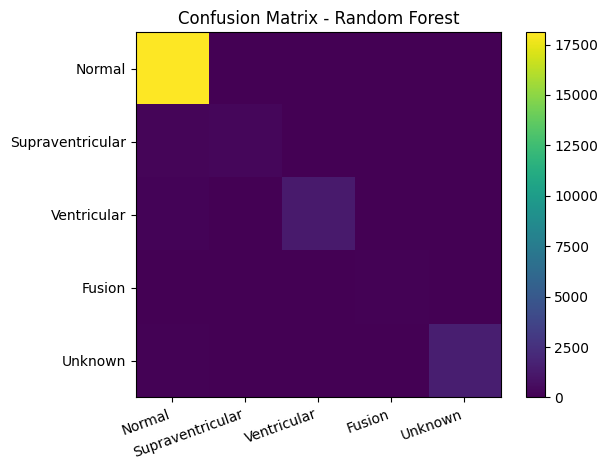

array([[18104,     4,     8,     0,     2],
       [  216,   338,     1,     0,     1],
       [  154,     0,  1275,    14,     5],
       [   47,     0,    12,   103,     0],
       [   88,     0,     2,     0,  1518]])

In [ ]:
print(classification_report(y_test, rf_pred, target_names=class_names, digits=2))

rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure()
plt.imshow(rf_cm)
plt.xticks(range(5), class_names, rotation=20, ha="right")
plt.yticks(range(5), class_names)
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()
plt.tight_layout()
plt.show()

rf_cm


                  precision    recall  f1-score   support

          Normal       0.97      1.00      0.99     18118
Supraventricular       0.99      0.61      0.75       556
     Ventricular       0.98      0.88      0.93      1448
          Fusion       0.88      0.64      0.74       162
         Unknown       0.99      0.94      0.97      1608

        accuracy                           0.97     21892
       macro avg       0.96      0.81      0.87     21892
    weighted avg       0.97      0.97      0.97     21892



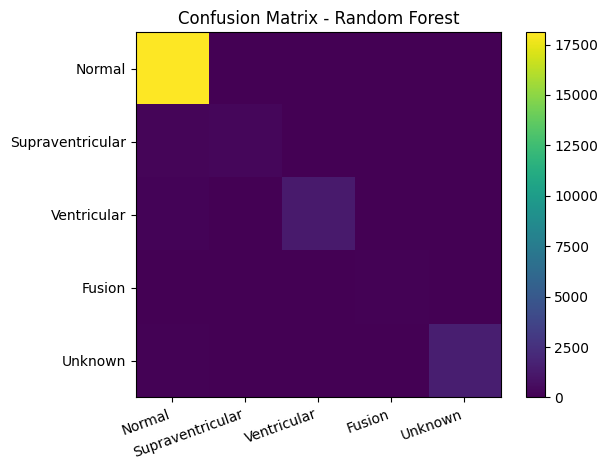

array([[18104,     4,     8,     0,     2],
       [  216,   338,     1,     0,     1],
       [  154,     0,  1275,    14,     5],
       [   47,     0,    12,   103,     0],
       [   88,     0,     2,     0,  1518]])

In [ ]:
print(classification_report(y_test, rf_pred, target_names=class_names, digits=2))

rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure()
plt.imshow(rf_cm)
plt.xticks(range(5), class_names, rotation=20, ha="right")
plt.yticks(range(5), class_names)
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()
plt.tight_layout()
plt.show()

rf_cm


In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

pd.Series(y_train_sm).value_counts().sort_index()


,count
0,72471
1,72471
2,72471
3,72471
4,72471


In [ ]:
X_train_sm = X_train_sm[..., np.newaxis].astype(np.float32)
X_test_cnn = X_test[..., np.newaxis].astype(np.float32)

y_train_sm_oh = tf.keras.utils.to_categorical(y_train_sm, 5)
y_test_oh     = tf.keras.utils.to_categorical(y_test, 5)

X_train_sm.shape, X_test_cnn.shape


((362355, 187, 1), (21892, 187, 1))

In [ ]:
model = models.Sequential([
    layers.Input(shape=(187, 1)),
    layers.Conv1D(32, 5, activation="relu", padding="same"),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, 5, activation="relu", padding="same"),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(5, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       188,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,005 (875.02 KB)

 Trainable params: 224,005 (875.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_sm,
    y_train_sm_oh,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)


Epoch 1/30
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 191s 166ms/step - accuracy: 0.8262 - loss: 0.4646 - val_accuracy: 0.9266 - val_loss: 0.2156
Epoch 2/30
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 203s 168ms/step - accuracy: 0.9533 - loss: 0.1339 - val_accuracy: 0.9507 - val_loss: 0.1354
Epoch 3/30
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 189s 157ms/step - accuracy: 0.9689 - loss: 0.0896 - val_accuracy: 0.9699 - val_loss: 0.0856
Epoch 4/30
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 177s 156ms/step - accuracy: 0.9767 - loss: 0.0677 - val_accuracy: 0.9794 - val_loss: 0.0645
Epoch 5/30
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 204s 158ms/step - accuracy: 0.9814 - loss: 0.0553 - val_accuracy: 0.9791 - val_loss: 0.0611
Epoch 6/30
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 202s 159ms/step - accuracy: 0.9844 - loss: 0.0464 - val_accuracy: 0.9823 - val_loss: 0.0551
Epoch 7/30
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 200s 157ms/step - accuracy: 0.9867 - loss: 0.0399 - val_accuracy: 0.9844 - val_loss: 0.0507
Epoch 8/30
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 181s 159ms/step - ac

In [ ]:
test_loss, test_acc = model.evaluate(X_test_cnn, y_test_oh, verbose=0)
test_acc


0.9783482551574707

685/685 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step
                  precision    recall  f1-score   support

          Normal       0.99      0.99      0.99     18118
Supraventricular       0.72      0.82      0.77       556
     Ventricular       0.95      0.95      0.95      1448
          Fusion       0.69      0.87      0.77       162
         Unknown       0.99      0.98      0.99      1608

        accuracy                           0.98     21892
       macro avg       0.87      0.92      0.89     21892
    weighted avg       0.98      0.98      0.98     21892



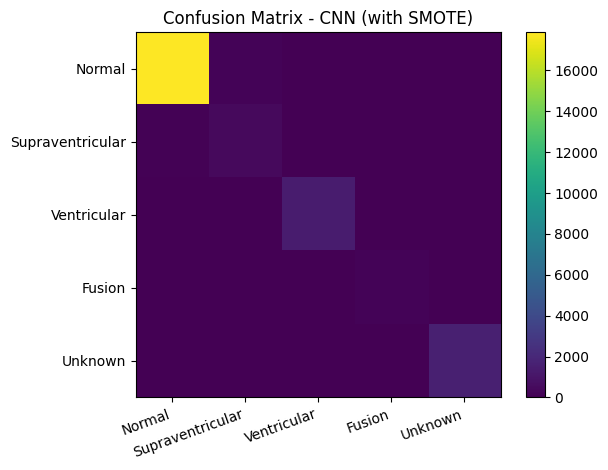

array([[17867,   164,    44,    38,     5],
       [   89,   457,     9,     0,     1],
       [   35,     6,  1378,    24,     5],
       [    9,     3,     9,   141,     0],
       [   23,     2,     8,     0,  1575]])

In [ ]:
cnn_pred = np.argmax(model.predict(X_test_cnn), axis=1)

print(classification_report(y_test, cnn_pred, target_names=class_names, digits=2))

cnn_cm = confusion_matrix(y_test, cnn_pred)

plt.figure()
plt.imshow(cnn_cm)
plt.xticks(range(5), class_names, rotation=20, ha="right")
plt.yticks(range(5), class_names)
plt.title("Confusion Matrix - CNN (with SMOTE)")
plt.colorbar()
plt.tight_layout()
plt.show()

cnn_cm


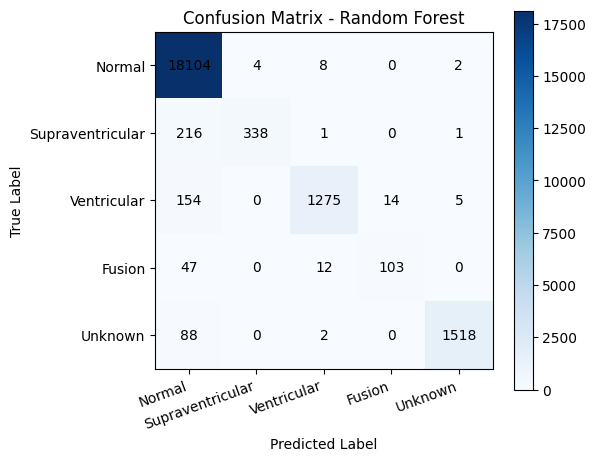

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,5))
plt.imshow(rf_cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=20, ha="right")
plt.yticks(tick_marks, class_names)

for i in range(rf_cm.shape[0]):
    for j in range(rf_cm.shape[1]):
        plt.text(j, i, rf_cm[i, j],
                 ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("rf_confusion.png", dpi=300, bbox_inches="tight")
plt.show()


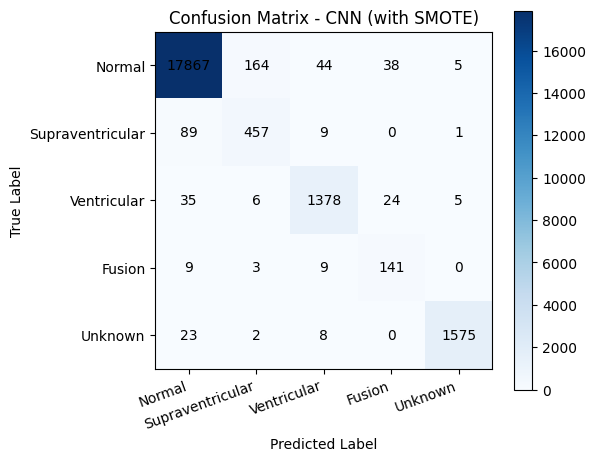

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(cnn_cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - CNN (with SMOTE)")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=20, ha="right")
plt.yticks(tick_marks, class_names)

for i in range(cnn_cm.shape[0]):
    for j in range(cnn_cm.shape[1]):
        plt.text(j, i, cnn_cm[i, j],
                 ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("cnn_confusion.png", dpi=300, bbox_inches="tight")
plt.show()
